# Análisis y modelamiento

In [1]:
!pip install pyreadstat


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pyreadstat
from IPython.core.display import display, HTML
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import os
import requests
import plotly.io as pio
pio.renderers.default = "notebook"  # Para Jupyter Notebook
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
# Set the renderer explicitly
pio.renderers.default = 'notebook'

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import geopandas as gpd
import unicodedata


C:\Users\henry\AppData\Local\Temp\ipykernel_40100\1894033739.py:10: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display



In [5]:
data_path = 'C:/Users/henry/Documents/jbook/Cacervix/datos/'
# data = pyreadstat.read_sav(data_path + 'CACU1985A2023.sav')
# enfermedades = pd.read_excel(data_path + 'enfermedades.xlsx')
# poblacion_mujeres = pd.read_excel(data_path + 'poblacion_mujeres.xlsx')
data = pd.read_excel(data_path + 'data_final.xlsx')

In [9]:
del data['AÑO.1']

In [10]:
display(HTML(data.tail().to_html()))

,DEPARTAMENTO,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,AÑO,MES,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,FECHA,AREA_DEFUN,SITIO_DEFUN,ETNIA,AREA DE RESIDENCIA,SEGURIDAD SOCIAL,C_PAT1_DESCRIPCION,C_ANT3_DESCRIPCION,C_ANT2_DESCRIPCION,C_ANT1_DESCRIPCION,C_DIR1_DESCRIPCION,Total Mujeres,PIB
58930,RISARALDA,RISARALDA,PEREIRA,PEREIRA,2023,12,Femenino,Soltero,Primaria,35-39,2023-12,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Subsidiado,No patología,No patología,No patología,No patología,No patología,191824,26404.0
58931,AMAZONAS,AMAZONAS,LETICIA,LETICIA,2023,4,Femenino,Soltero,Superior,50-54,2023-04,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Subsidiado,No patología,No patología,No patología,No patología,No patología,3543877,1213.0
58932,META,META,VILLAVICENCIO,VILLAVICENCIO,2023,11,Femenino,Viudo,Secundaria,45-49,2023-11,URBANA,OTRO SITIO,Ninguno de las anteriores,Cabecera municipal,Vinculado,No patología,No patología,No patología,No patología,No patología,495605,53797.0
58933,VALLE DEL CAUCA,VALLE DEL CAUCA,CALI,CALI,2023,1,Femenino,"Unión Libre, divorciado, otro",Primaria,75-79,2023-01,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Subsidiado,No patología,No patología,No patología,No patología,No patología,46584,153564.0
58934,"BOGOTÁ, D.C.","BOGOTÁ, D.C.",BOGOTÁ D.C.,BOGOTÁ D.C.,2023,12,Femenino,Casado,Secundaria,70-74,2023-12,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Contributivo,No patología,No patología,No patología,No patología,No patología,537565,395438.0


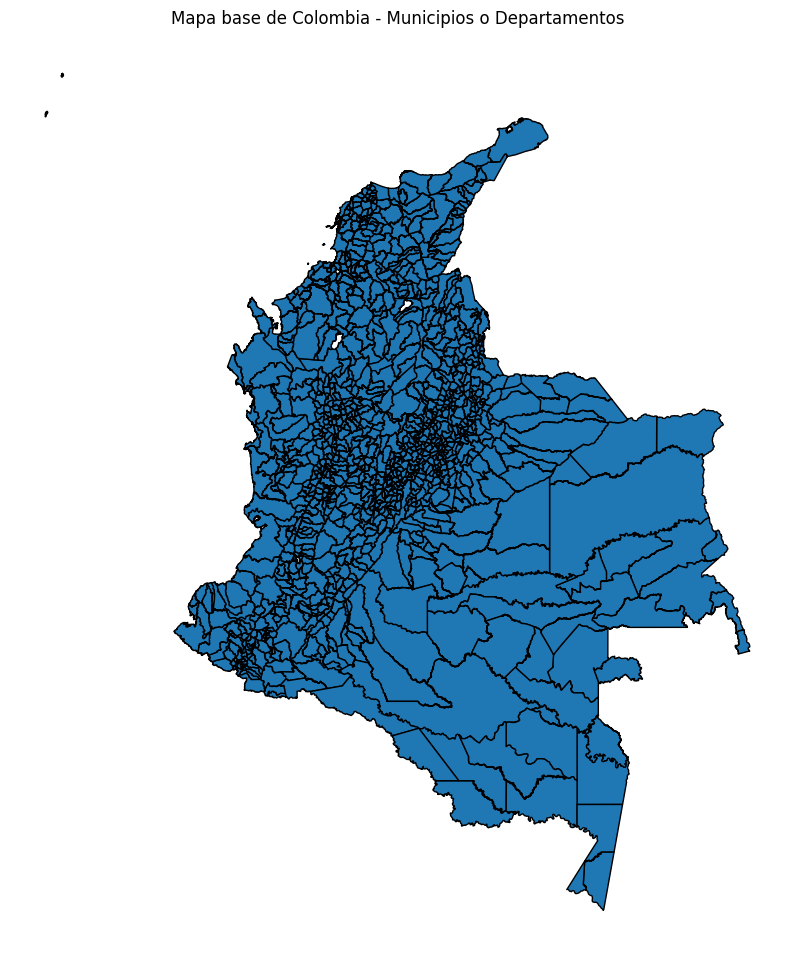

In [98]:
shapefile_path = (data_path + "Municipios/Municipios.shp")
colombia = gpd.read_file(shapefile_path)

# print(colombia.head())
colombia.plot(edgecolor='black', figsize=(10, 12))
plt.title("Mapa base de Colombia - Municipios o Departamentos")
plt.axis("off")
plt.show()

In [109]:
def normalizar(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).upper()
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    return texto

### Crear variable para comorbilidad

In [11]:
cols_comorbilidades = [
    "C_PAT1_DESCRIPCION",
    "C_ANT1_DESCRIPCION",
    "C_ANT2_DESCRIPCION",
    "C_ANT3_DESCRIPCION",
    "C_DIR1_DESCRIPCION"
]


Se crea variable de si tiene o no tiene comorbilidad

In [12]:
# Variable binaria: Tiene al menos una comorbilidad (distinta de "No patología")
data["TIENE_COMORBILIDAD"] = data[cols_comorbilidades].apply(
    lambda row: any(str(val).strip().lower() != "no patología" for val in row),
    axis=1
)

# Conteo de comorbilidades presentes
data["NUM_COMORBILIDADES"] = data[cols_comorbilidades].apply(
    lambda row: sum(1 for val in row if str(val).strip().lower() != "no patología"),
    axis=1
)

In [25]:
# Guardar el archivo actualizado
output_path = "C:/Users/henry/Documents/jbook/Cacervix/datos/data_comorbilidades_actualizadas.xlsx"
data.to_excel(output_path, index=False)

output_path

'C:/Users/henry/Documents/jbook/Cacervix/datos/data_comorbilidades_actualizadas.xlsx'

In [26]:
data = pd.read_excel(data_path + 'data_comorbilidades_actualizadas.xlsx')

In [18]:
display(HTML(data.tail().to_html()))

,DEPARTAMENTO,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,AÑO,MES,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,FECHA,AREA_DEFUN,SITIO_DEFUN,ETNIA,AREA DE RESIDENCIA,SEGURIDAD SOCIAL,C_PAT1_DESCRIPCION,C_ANT3_DESCRIPCION,C_ANT2_DESCRIPCION,C_ANT1_DESCRIPCION,C_DIR1_DESCRIPCION,Total Mujeres,PIB,TIENE_COMORBILIDAD,NUM_COMORBILIDADES
58930,RISARALDA,RISARALDA,PEREIRA,PEREIRA,2023,12,Femenino,Soltero,Primaria,35-39,2023-12,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Subsidiado,No patología,No patología,No patología,No patología,No patología,191824,26404.0,False,0
58931,AMAZONAS,AMAZONAS,LETICIA,LETICIA,2023,4,Femenino,Soltero,Superior,50-54,2023-04,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Subsidiado,No patología,No patología,No patología,No patología,No patología,3543877,1213.0,False,0
58932,META,META,VILLAVICENCIO,VILLAVICENCIO,2023,11,Femenino,Viudo,Secundaria,45-49,2023-11,URBANA,OTRO SITIO,Ninguno de las anteriores,Cabecera municipal,Vinculado,No patología,No patología,No patología,No patología,No patología,495605,53797.0,False,0
58933,VALLE DEL CAUCA,VALLE DEL CAUCA,CALI,CALI,2023,1,Femenino,"Unión Libre, divorciado, otro",Primaria,75-79,2023-01,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Subsidiado,No patología,No patología,No patología,No patología,No patología,46584,153564.0,False,0
58934,"BOGOTÁ, D.C.","BOGOTÁ, D.C.",BOGOTÁ D.C.,BOGOTÁ D.C.,2023,12,Femenino,Casado,Secundaria,70-74,2023-12,URBANA,HOSPITAL O CLÍNICA,Ninguno de las anteriores,Cabecera municipal,Contributivo,No patología,No patología,No patología,No patología,No patología,537565,395438.0,False,0


## Clustering general por zona rural vs urbana

#### Dividimos los datos en rurales vs urbanos

In [48]:
urbana_data = data[data["AREA DE RESIDENCIA"].str.lower().str.contains("cabecera")]
rural_data = data[~data["AREA DE RESIDENCIA"].str.lower().str.contains("cabecera")]

# Mostrar la cantidad de registros en cada subdataset
len(urbana_data), len(rural_data)

(49411, 9524)

Seleccionamos las variables a utilizar y hacemos el análisis para rural

In [50]:
# Variables seleccionadas
vars_categoricas = [
    "DEPARTAMENTO DE RESIDENCIA", "MUNICIPIO DE RESIDENCIA",
    "ESTADO_CIVIL", "NIVEL_EDUCACION", "GRUPO_ETARIO",
    "ETNIA", "SEGURIDAD SOCIAL"
]

vars_numericas = ["PIB", "TIENE_COMORBILIDAD", "NUM_COMORBILIDADES"]

Transformas y estandarizamos las variables a utilizar

In [51]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), vars_categoricas),
    ("num", StandardScaler(), vars_numericas)
])

In [52]:
X_processed = preprocessor.fit_transform(rural_data)

In [53]:
# Validación del número óptimo de clusters con Silhouette Score
silhouette_scores = []
k_range = range(2, 10)

In [54]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)

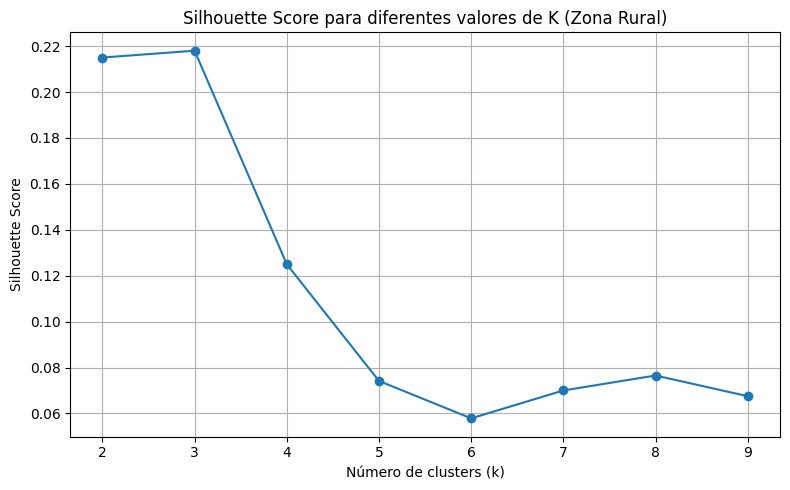

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score para diferentes valores de K (Zona Rural)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

Se ajusta el cluster con k= 3

In [56]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

In [57]:
pipeline.fit(rural_data)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DEPARTAMENTO DE RESIDENCIA',
                                                   'MUNICIPIO DE RESIDENCIA',
                                                   'ESTADO_CIVIL',
                                                   'NIVEL_EDUCACION',
                                                   'GRUPO_ETARIO', 'ETNIA',
                                                   'SEGURIDAD SOCIAL']),
                                                 ('num', StandardScaler(),
                                                  ['PIB', 'TIENE_COMORBILIDAD',
                                                   'NUM_COMORBILIDADES'])])),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

In [58]:
# Obtener etiquetas y agregarlas al DataFrame
rural_data["CLUSTER"] = pipeline.named_steps["kmeans"].labels_

C:\Users\henry\AppData\Local\Temp\ipykernel_40100\567699832.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [59]:
rural_data.to_excel("rural_data_cluster_general_k3.xlsx", index=False)

#### Resumen y agrupación de los clusteres rurales

In [60]:
numeric_summary = rural_data.groupby("CLUSTER")[["PIB", "NUM_COMORBILIDADES", "TIENE_COMORBILIDAD"]].mean()

# Moda de variables categóricas por cluster
categorical_vars = ["DEPARTAMENTO DE RESIDENCIA", "MUNICIPIO", "MUNICIPIO DE RESIDENCIA",
    "SEX", "ESTADO_CIVIL", "NIVEL_EDUCACION", "GRUPO_ETARIO",
    "ETNIA", "SEGURIDAD SOCIAL"]
categorical_summary = rural_data.groupby("CLUSTER")[categorical_vars].agg(lambda x: x.mode().iloc[0])


In [61]:
cluster_summary = pd.concat([numeric_summary, categorical_summary], axis=1)

In [62]:
cluster_summary

,PIB,NUM_COMORBILIDADES,TIENE_COMORBILIDAD,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,ETNIA,SEGURIDAD SOCIAL
CLUSTER,,,,,,,,,,,,
0,24737.945138,2.486524,1.000000,ANTIOQUIA,"BOGOTÁ, D.C.",PASTO,Femenino,Soltero,Primaria,50-54,Ninguno de las anteriores,Subsidiado
1,221513.898662,0.873805,0.338432,ANTIOQUIA,"BOGOTÁ, D.C.",MEDELLÍN,Femenino,Soltero,Primaria,60-64,Ninguno de las anteriores,Subsidiado
2,16047.992037,0.000000,0.000000,CAUCA,MONTERÍA,MONTERÍA,Femenino,Soltero,Primaria,55-59,Ninguno de las anteriores,Subsidiado


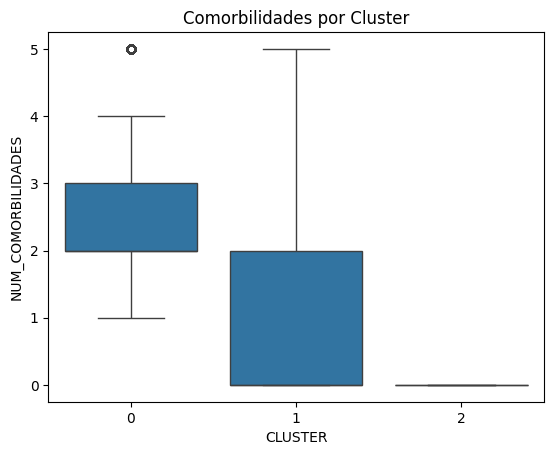

In [63]:
sns.boxplot(data=rural_data, x="CLUSTER", y="NUM_COMORBILIDADES")
plt.title("Comorbilidades por Cluster")
plt.show()

#### Ubicación geográfica de cada cluster

In [101]:
# Agrupar por municipio para obtener el cluster más común
cluster_por_mpio = rural_data.groupby("MUNICIPIO DE RESIDENCIA")["CLUSTER"] \
    .agg(lambda x: x.value_counts().idxmax()).reset_index()

# Renombrar la columna para que coincida con el shapefile
cluster_por_mpio.rename(columns={"MUNICIPIO DE RESIDENCIA": "MPIO_CNMBR"}, inplace=True)

In [ ]:
print(colombia.columns)  

Index(['OBJECTID_1', 'DPTO_CCDGO', 'MPIO_CCDGO', 'Shape_Leng', 'OBJECTID',
       'MPIO_CNMBR', 'DESCRPCION', 'DEPTO', 'P_ENERSI', 'P_ENERNO',
       'P_ALCANSI', 'P_ALCANNO', 'P_ACUESI', 'P_ACUENO', 'P_GASNSI',
       'P_GASNNO', 'P_GASNNOIN', 'P_TELEFSI', 'P_TELEFNO', 'P_TELEFNOI',
       'ShapeSTAre', 'ShapeSTLen', 'geometry'],
      dtype='object')


In [102]:
cluster_por_mpio["MPIO_CNMBR"] = cluster_por_mpio["MPIO_CNMBR"].str.upper()
colombia["MPIO_CNMBR"] = colombia["MPIO_CNMBR"].str.upper() #Mayúscyla

In [110]:
cluster_por_mpio["MPIO_CNMBR"] = cluster_por_mpio["MPIO_CNMBR"].apply(normalizar)
colombia["MPIO_CNMBR"] = colombia["MPIO_CNMBR"].apply(normalizar)

In [112]:
# Merge del shapefile con la información del cluster por municipio
colombia_clusterizada = colombia.merge(cluster_por_mpio, on="MPIO_CNMBR", how="left")


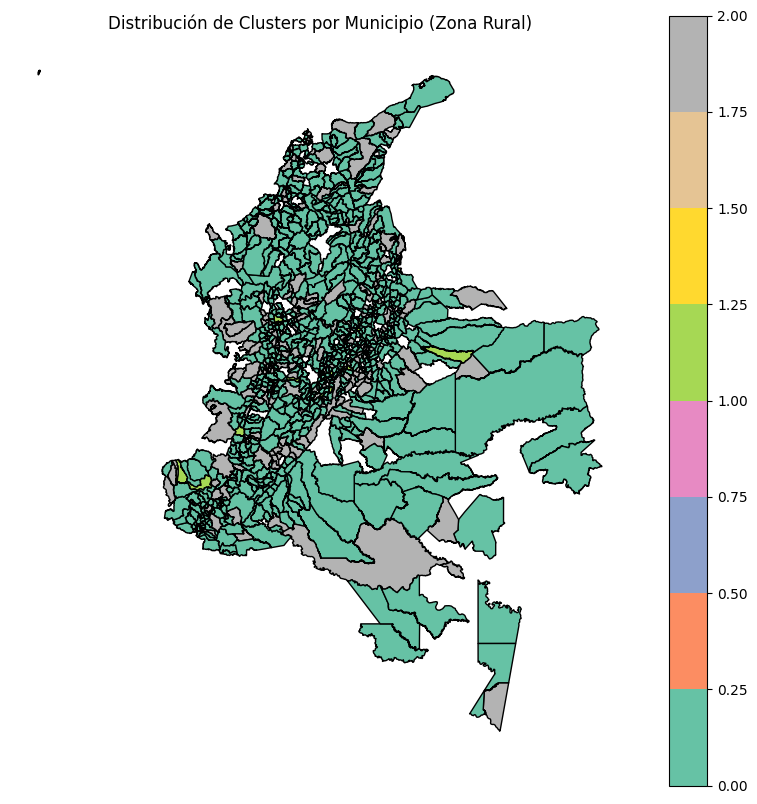

In [115]:
colombia_clusterizada.plot(
    column="CLUSTER",
    cmap="Set2",
    legend=True,
    edgecolor="black",
    figsize=(10, 10)
)
plt.title("Distribución de Clusters por Municipio (Zona Rural)")
plt.axis("off")
plt.show()

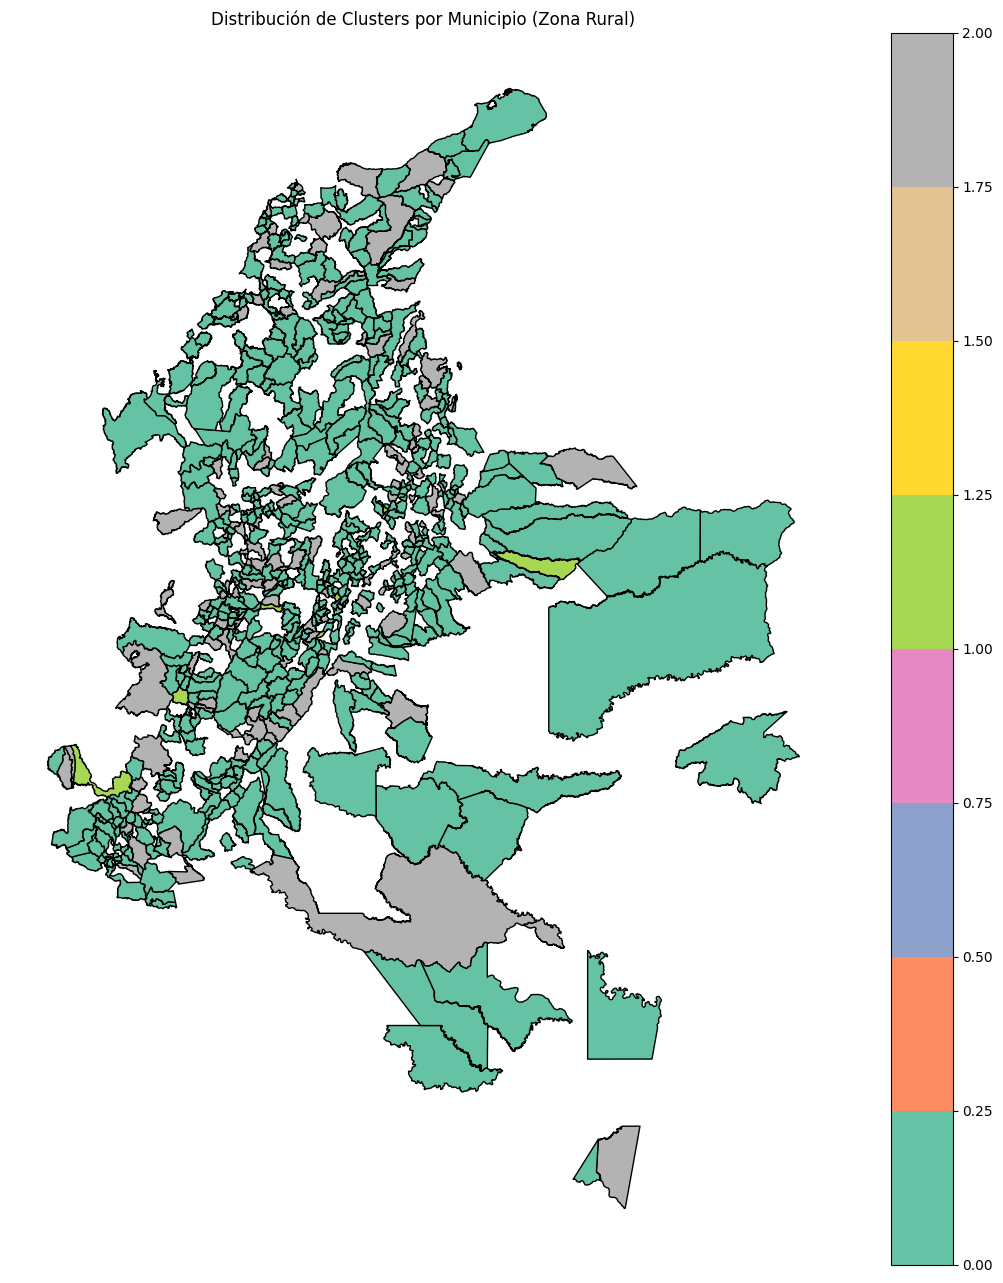

In [111]:
colombia_clusterizada.plot(
    column="CLUSTER",
    cmap="Set2",
    legend=True,
    edgecolor="black",
    figsize=(14, 16)
)
plt.title("Distribución de Clusters por Municipio (Zona Rural)")
plt.axis("off")
plt.show()

In [107]:
municipios_unidos = cluster_por_mpio["MPIO_CNMBR"].unique()
municipios_mapa = colombia["MPIO_CNMBR"].unique()

faltantes = set(municipios_mapa) - set(municipios_unidos)
print("Municipios sin cluster asignado:", len(faltantes))
print(faltantes)

Municipios sin cluster asignado: 428
{'NEMOCON', 'PUERTO ARICA', 'JUNIN', 'PARAMO', 'CHIPATA', 'UBATE', 'SAN ANDRES SOTAVENTO', 'CIENAGA DE ORO', 'JORDAN', 'CERRO SAN ANTONIO', 'COLON', 'LIBANO', 'TIMANA', 'HATONUEVO', 'SAN SEBASTIAN DE BUENAVISTA', 'SAN AGUSTIN', 'EL PLAYON', 'SAN MARTIN', 'TUQUERRES', 'SAN ZENON', 'SORACA', 'CEPITA', 'ITSMINA', 'PROVIDENCIA Y SANTA CATALINA', 'RAQUIRA', 'CALARCA', 'CACAHUAL', 'BUSBANZA', 'SOPLAVIENTO', 'CONDOTO', 'CARMEN DE APICALA', 'PUERTO ALEGRIA', 'EL CARMEN DE BOLIVAR', 'OROCUE', 'ENCINO', 'ALBAN', 'PIOJO', 'GUACHETA', 'LANDAZURI', 'BARICHARA', 'SOMONDOCO', 'ROBERTO PAYAN', 'CHACHAGUI', 'YOLOMBO', 'SAN MARTIN DE LOBA', 'EBEJICO', 'GAMBITA', 'TUBARA', 'PALMAR DE VARELA', 'BOLIVAR', 'FUQUENE', 'TOGUI', 'GUATICA', 'SIMITI', 'ANGELOPOLIS', 'CURITI', 'YONDO', 'MAPIRIPAN', 'CAPARRAPI', 'ANZOATEGUI', 'VILLA MARIA', 'EL RETEN', 'ARBELAEZ', 'CURRILLO', 'LOURDES', 'SAN ROSA VITERBO', 'CORRALES', 'PEDRAZA', 'BELEN DE UMBRIA', 'ABRIAQUI', 'CUCAITA', 'SAN JU

#### Cluster para zona urbana

In [65]:
X_processed = preprocessor.fit_transform(urbana_data)

In [66]:
silhouette_scores = []
k_range = range(2, 10)

In [67]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)

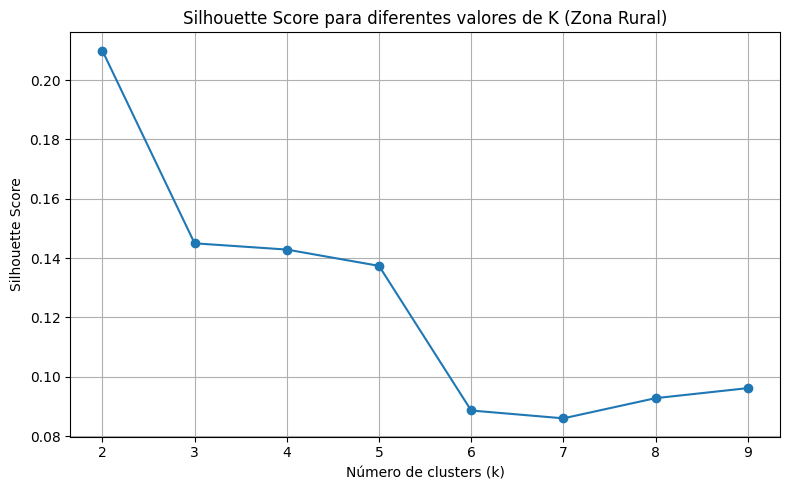

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score para diferentes valores de K (Zona Rural)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("kmeans", KMeans(n_clusters=2, random_state=42))
])

In [81]:
pipeline.fit(urbana_data)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DEPARTAMENTO DE RESIDENCIA',
                                                   'MUNICIPIO DE RESIDENCIA',
                                                   'ESTADO_CIVIL',
                                                   'NIVEL_EDUCACION',
                                                   'GRUPO_ETARIO', 'ETNIA',
                                                   'SEGURIDAD SOCIAL']),
                                                 ('num', StandardScaler(),
                                                  ['PIB', 'TIENE_COMORBILIDAD',
                                                   'NUM_COMORBILIDADES'])])),
                ('kmeans', KMeans(n_clusters=2, random_state=42))])

In [82]:
urbana_data["CLUSTER"] = pipeline.named_steps["kmeans"].labels_

C:\Users\henry\AppData\Local\Temp\ipykernel_40100\1805390220.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [83]:
urbana_data.to_excel("urban_data_cluster_general_k2.xlsx", index=False)

In [84]:
numeric_summary_urbana = urbana_data.groupby("CLUSTER")[["PIB", "NUM_COMORBILIDADES", "TIENE_COMORBILIDAD"]].mean()

# Moda de variables categóricas por cluster
categorical_vars = ["DEPARTAMENTO DE RESIDENCIA", "MUNICIPIO", "MUNICIPIO DE RESIDENCIA",
    "SEX", "ESTADO_CIVIL", "NIVEL_EDUCACION", "GRUPO_ETARIO",
    "ETNIA", "SEGURIDAD SOCIAL"]
categorical_summary_urbana = urbana_data.groupby("CLUSTER")[categorical_vars].agg(lambda x: x.mode().iloc[0])

In [85]:
cluster_summary_urbana = pd.concat([numeric_summary_urbana, categorical_summary_urbana], axis=1)

In [87]:
cluster_summary_urbana

,PIB,NUM_COMORBILIDADES,TIENE_COMORBILIDAD,DEPARTAMENTO DE RESIDENCIA,MUNICIPIO,MUNICIPIO DE RESIDENCIA,SEX,ESTADO_CIVIL,NIVEL_EDUCACION,GRUPO_ETARIO,ETNIA,SEGURIDAD SOCIAL
CLUSTER,,,,,,,,,,,,
0,45890.203780,2.565926,1.0,"BOGOTÁ, D.C.","BOGOTÁ, D.C.","BOGOTÁ, D.C.",Femenino,Soltero,Primaria,50-54,Ninguno de las anteriores,Subsidiado
1,44287.857854,0.000000,0.0,"BOGOTÁ, D.C.","BOGOTÁ, D.C.","BOGOTÁ, D.C.",Femenino,Soltero,Primaria,50-54,Ninguno de las anteriores,Subsidiado


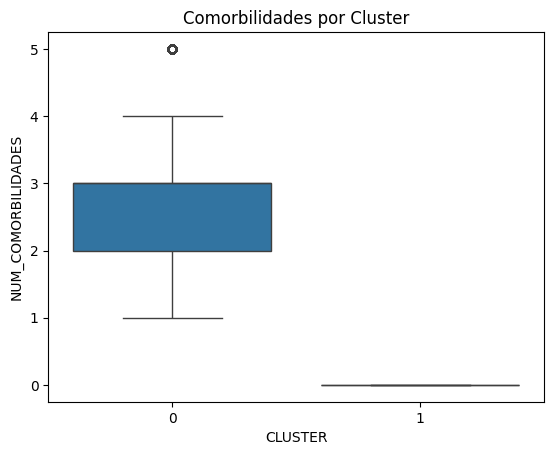

In [88]:
sns.boxplot(data=urbana_data, x="CLUSTER", y="NUM_COMORBILIDADES")
plt.title("Comorbilidades por Cluster")
plt.show()

Mostrar los clusteres en el mapa de colombia